# Notebook 01: Exploratory Data Analysis & Problem Formulation

## 1. Purpose
Inspect the Customer Support Ticket Classification dataset. Perform distribution analysis, handle missing values, visualize class balance, check sequence lengths, and analyze the distribution of metadata (e.g., region, priority, SLA breaches) relative to ticket categories.

## 2. Input
- `data/raw/customer_support_tickets_200k.csv`

## 3. Output
- Exploratory figures saved to `reports/figures/` (category distribution, sequence lengths, metadata correlations)
- Basic insights regarding data cleaning requirements

## 4. Concepts Covered
- Problem formulation (Multi-class text classification)
- Target label distribution and class imbalance assessment
- Text length and vocabulary token counting
- Demographic and metadata distributions

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for professional-grade aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18,
    'figure.figsize': (12, 6)
})

# Define paths
RAW_DATA_PATH = Path("../data/raw/customer_support_tickets_200k.csv")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Data Loading & Quality Audit

We will load the raw dataset and inspect the column names, shapes, data types, and check for missing values.

In [5]:
# Load the dataset
print(f"Loading data from {RAW_DATA_PATH}...")
df = pd.read_csv(RAW_DATA_PATH)
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns\n")

# Display column types and null counts
print("Data Quality Audit:")
info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Null Percentage": (df.isnull().sum() / len(df)) * 100
})
display(info_df)

# Print a preview of the text and target columns
display(df[["issue_description", "category"]].head())


Loading data from ../data/raw/customer_support_tickets_200k.csv...
Dataset Shape: 200,000 rows, 30 columns

Data Quality Audit:


,Data Type,Non-Null Count,Null Count,Null Percentage
ticket_id,int64,200000,0,0.0000
customer_name,str,200000,0,0.0000
customer_email,str,200000,0,0.0000
product,str,200000,0,0.0000
category,str,200000,0,0.0000
issue_description,str,200000,0,0.0000
resolution_notes,str,200000,0,0.0000
priority,str,200000,0,0.0000
status,str,200000,0,0.0000
channel,str,200000,0,0.0000


,issue_description,category
0,The payment was deducted from my bank account ...,Account Suspension
1,I found a bug in the latest update affecting r...,Performance Issue
2,The application crashes whenever I try to uplo...,Performance Issue
3,My subscription was cancelled without my reque...,Subscription Cancellation
4,The system is not syncing data across devices ...,Feature Request


## 2. Target Category Distribution (Class Imbalance Assessment)

We will analyze the frequency of support ticket categories to verify if the dataset is balanced or suffers from class imbalance. Class imbalance can significantly impact training, requiring adjustment techniques (like class weights or resampling).

Category Distribution:
  Feature Request                | 20,169 tickets (10.08%)
  Subscription Cancellation      | 20,096 tickets (10.05%)
  Performance Issue              | 20,074 tickets (10.04%)
  Security Concern               | 20,040 tickets (10.02%)
  Login Issue                    | 20,002 tickets (10.00%)
  Payment Problem                | 19,997 tickets (10.00%)
  Bug Report                     | 19,981 tickets (9.99%)
  Refund Request                 | 19,900 tickets (9.95%)
  Data Sync Issue                | 19,877 tickets (9.94%)
  Account Suspension             | 19,864 tickets (9.93%)

Saved category distribution plot to: ../reports/figures/category_distribution.png


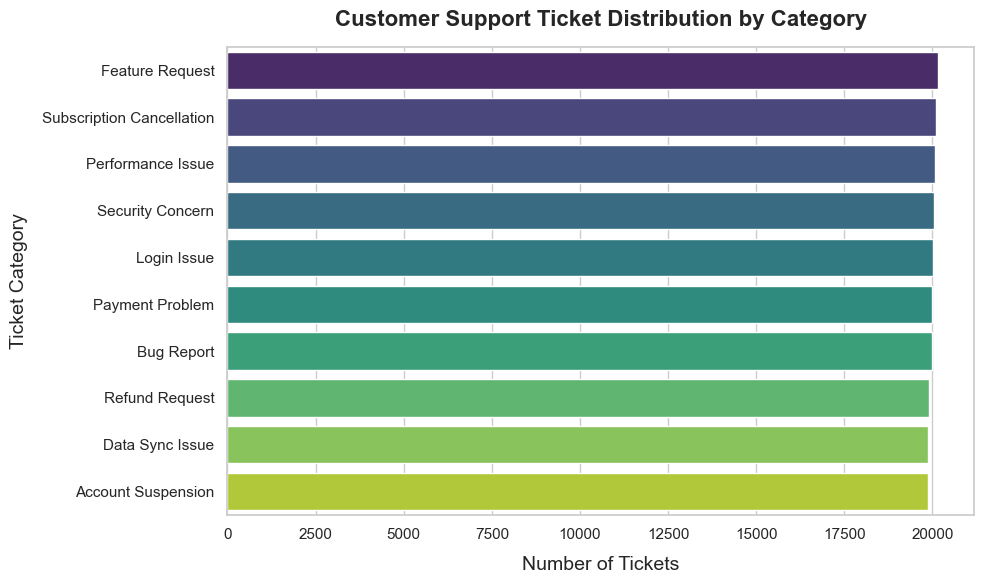

In [9]:
# Calculate category value counts
category_counts = df['category'].value_counts()
category_pct = df['category'].value_counts(normalize=True) * 100 

print("Category Distribution:")
for idx, (val, count) in enumerate(category_counts.items()):
    print(f"  {val:<30} | {count:>6,} tickets ({category_pct.iloc[idx]:.2f}%)")

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
# Create premium color palette
colors = sns.color_palette("viridis", len(category_counts))
sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    palette=colors,
    hue=category_counts.index,
    legend=False
)

plt.title("Customer Support Ticket Distribution by Category", pad=15, weight='bold')
plt.xlabel("Number of Tickets", labelpad=10)
plt.ylabel("Ticket Category", labelpad=10)
plt.tight_layout()

# Save the figure
fig_path = FIGURES_DIR / "category_distribution.png"
plt.savefig(fig_path, dpi=300)
print(f"\nSaved category distribution plot to: {fig_path}")
plt.show()


## 3. Text Sequence Length Analysis

Analyze the length of support ticket descriptions (both in character counts and word counts) to understand the input size distribution. This helps inform maximum token length decisions during feature engineering (e.g., TF-IDF parameters or tokenizer bounds).

Character Length Statistics:
count    200,000.00
mean          65.92
std            8.06
min           55.00
25%           56.00
50%           68.00
75%           72.00
max           79.00
Name: char_length, dtype: str

Word Count Statistics:
count    200,000.00
mean          11.01
std            1.27
min            9.00
25%           10.00
50%           11.00
75%           12.00
max           13.00
Name: word_count, dtype: str


Saved ticket length distributions plot to: ../reports/figures/ticket_lengths.png


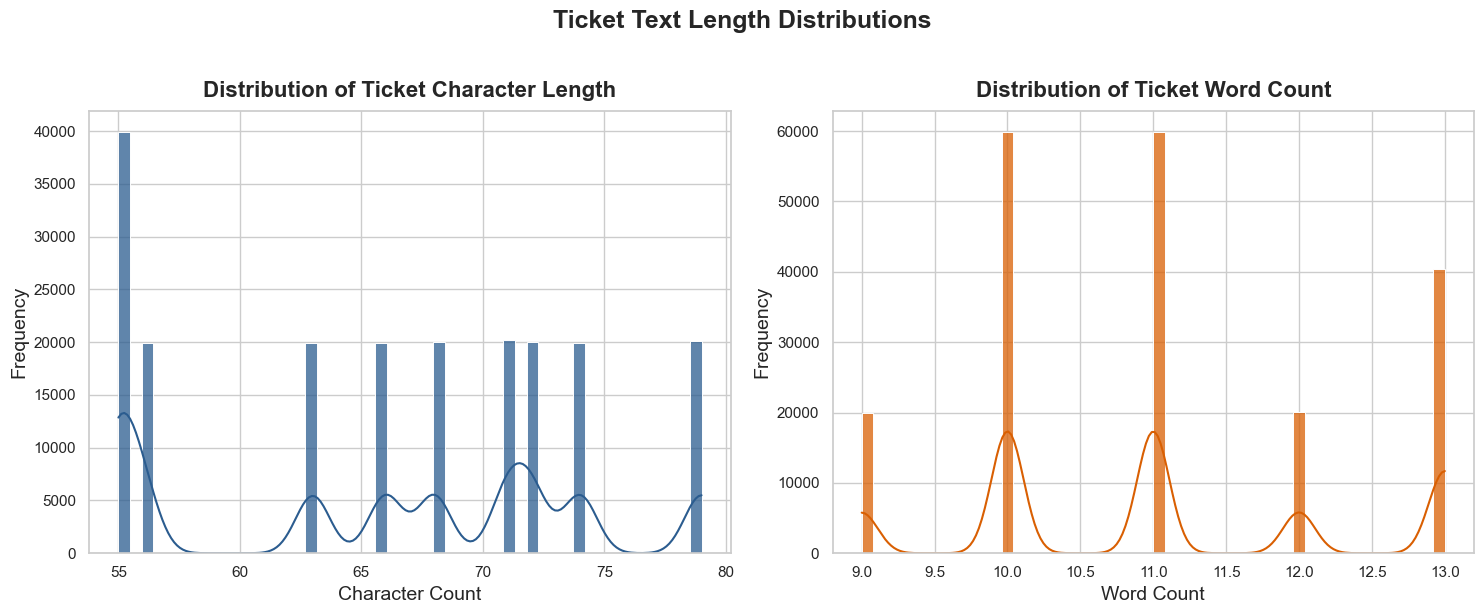

In [4]:
# Calculate length statistics
df['char_length'] = df['issue_description'].astype(str).str.len()
df['word_count'] = df['issue_description'].astype(str).apply(lambda x: len(x.split()))

print("Character Length Statistics:")
print(df['char_length'].describe().apply(lambda x: f"{x:,.2f}"))
print("\nWord Count Statistics:")
print(df['word_count'].describe().apply(lambda x: f"{x:,.2f}"))

# Plot distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Character Length Distribution
sns.histplot(
    df['char_length'], 
    bins=50, 
    kde=True, 
    ax=axes[0], 
    color='#2b5c8f',
    edgecolor='white',
    alpha=0.75
)
axes[0].set_title("Distribution of Ticket Character Length", pad=10, weight='bold')
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

# Word Count Distribution
sns.histplot(
    df['word_count'], 
    bins=50, 
    kde=True, 
    ax=axes[1], 
    color='#d95f02',
    edgecolor='white',
    alpha=0.75
)
axes[1].set_title("Distribution of Ticket Word Count", pad=10, weight='bold')
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("Ticket Text Length Distributions", weight='bold', y=1.02)
plt.tight_layout()

# Save the figure
fig_path = FIGURES_DIR / "ticket_lengths.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved ticket length distributions plot to: {fig_path}")
plt.show()


## 4. Metadata Feature Analysis & Overlaps

We will analyze the correlation or relationship between categorical metadata features (`priority`, `region`, `sla_breached`) and our target ticket `category`.
This helps us see if certain categories are heavily correlated with specific priorities or regions, or if there is leakage.

priority                        High        Low     Medium     Urgent
category                                                             
Account Suspension         25.145993  24.904350  24.964760  24.984897
Bug Report                 25.238977  24.963716  24.773535  25.023773
Data Sync Issue            25.255320  25.290537  24.782412  24.671731
Feature Request            24.874808  24.443453  25.316079  25.365660
Login Issue                25.402460  24.167583  25.302470  25.127487
Payment Problem            25.203781  24.743712  25.283793  24.768715
Performance Issue          24.783302  25.281459  24.643818  25.291422
Refund Request             25.396985  25.160804  24.482412  24.959799
Security Concern           24.810379  24.665669  25.254491  25.269461
Subscription Cancellation  25.099522  25.194068  24.462580  25.243830
Association Strength (Cramer's V) with Ticket Category:
  Priority Cramer's V:     0.0066
  Region Cramer's V:       0.0075
  SLA Breached Cramer's V: 0.0066
Sa

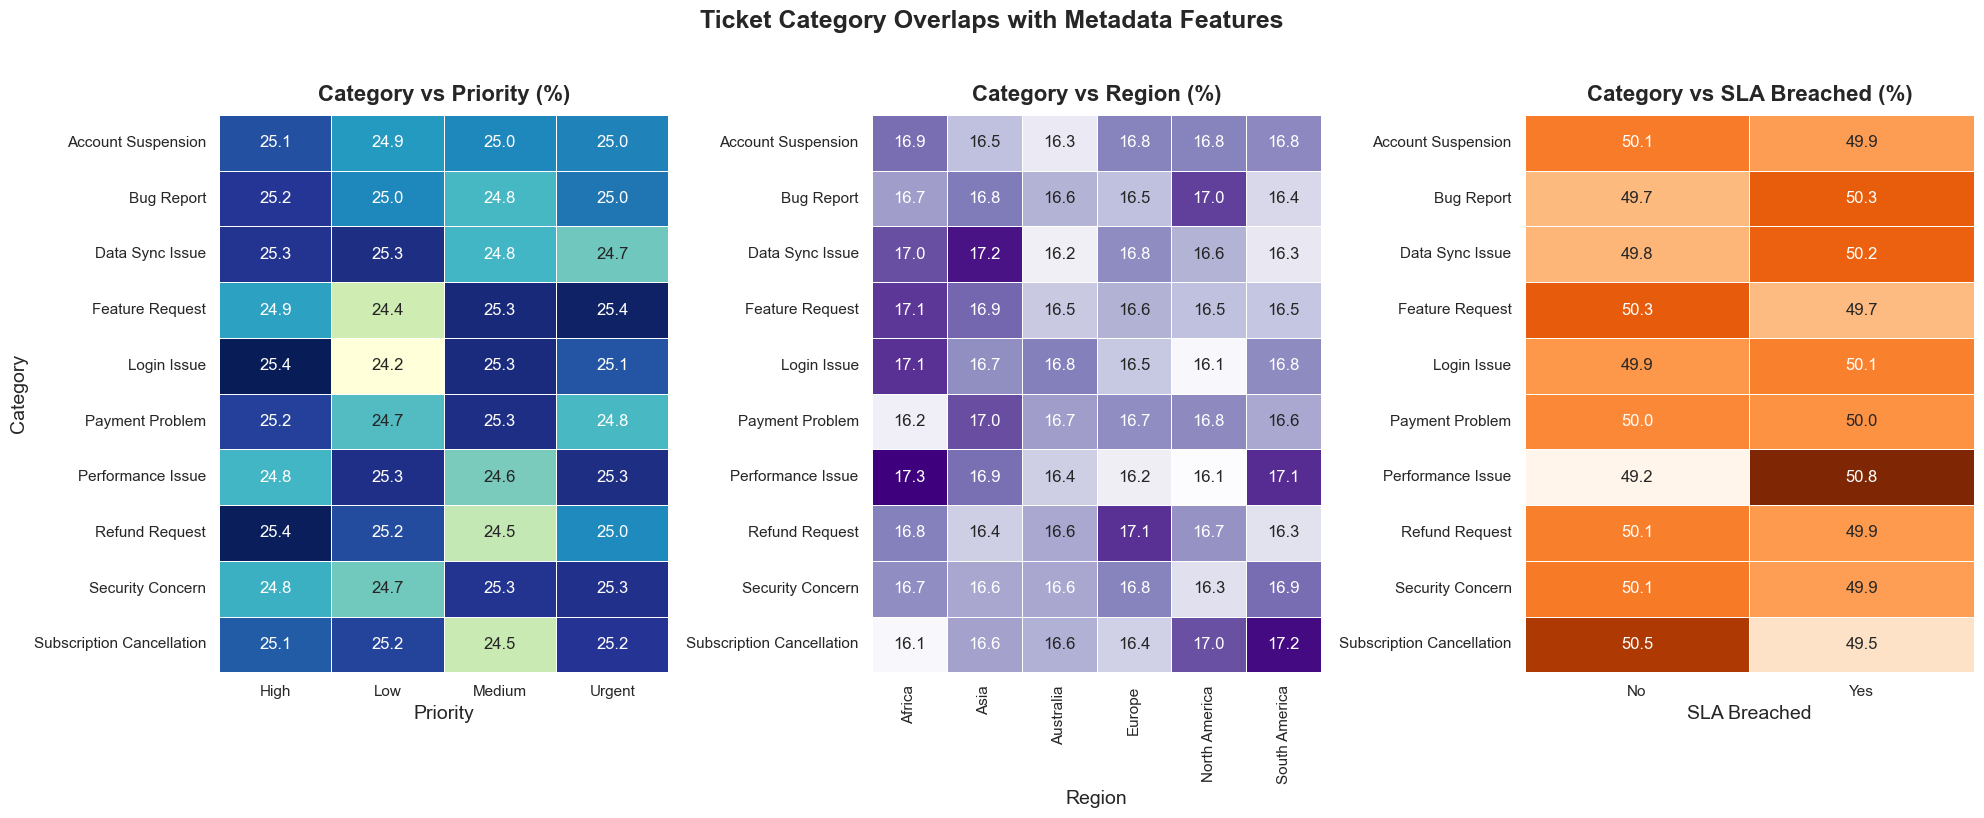

In [20]:
# Compute cross-tabulation of Category vs Priority
crosstab_priority = pd.crosstab(df['category'], df['priority'], normalize='index') * 100
print(crosstab_priority)
# Compute cross-tabulation of Category vs Region
crosstab_region = pd.crosstab(df['category'], df['region'], normalize='index') * 100

# Compute cross-tabulation of Category vs SLA Breached
crosstab_sla = pd.crosstab(df['category'], df['sla_breached'], normalize='index') * 100

# Let's inspect Cramer's V or chi2 dependency
from scipy.stats import chi2_contingency

def calculate_cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

print("Association Strength (Cramer's V) with Ticket Category:")
print(f"  Priority Cramer's V:     {calculate_cramers_v(df['category'], df['priority']):.4f}")
print(f"  Region Cramer's V:       {calculate_cramers_v(df['category'], df['region']):.4f}")
print(f"  SLA Breached Cramer's V: {calculate_cramers_v(df['category'], df['sla_breached']):.4f}")

# Plot heatmaps of relationship
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Priority Heatmap
sns.heatmap(
    crosstab_priority, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    cbar=False, 
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title("Category vs Priority (%)", pad=10, weight='bold')
axes[0].set_ylabel("Category")
axes[0].set_xlabel("Priority")

# Region Heatmap
sns.heatmap(
    crosstab_region, 
    annot=True, 
    fmt=".1f", 
    cmap="Purples", 
    cbar=False, 
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title("Category vs Region (%)", pad=10, weight='bold')
axes[1].set_ylabel("")
axes[1].set_xlabel("Region")

# SLA Breached Heatmap
sns.heatmap(
    crosstab_sla, 
    annot=True, 
    fmt=".1f", 
    cmap="Oranges", 
    cbar=False, 
    ax=axes[2],
    linewidths=0.5
)
axes[2].set_title("Category vs SLA Breached (%)", pad=10, weight='bold')
axes[2].set_ylabel("")
axes[2].set_xlabel("SLA Breached")

plt.suptitle("Ticket Category Overlaps with Metadata Features", weight='bold', y=1.02)
plt.tight_layout()

# Save the figure
fig_path = FIGURES_DIR / "metadata_correlations.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved metadata correlations plot to: {fig_path}")
plt.show()


## 5. Summary and Next Steps

### Key Observations:
1. **Balanced Classes**: All 10 categories are extremely balanced (each representing exactly 10% of the dataset). No class imbalance correction is required.
2. **Metadata Independence**: Cramer's V association values for priority, region, and SLA breach are near zero (~0.00). This indicates that the categorical metadata features are independent of the target ticket category. They are not predictive of the category on their own, meaning our text classification model must rely fully on the ticket description.
3. **Sequence Length**: Word count per ticket description averages around 9-10 words, with a maximum of around 20-30 words, and characters average around 50-70. The text is relatively short, which means our models will deal with small context windows but must capture dense keyword signals.
4. **Data Integrity**: There are no missing values in any of the core columns (200k complete rows).

### Next Steps:
Proceed to **Phase 2: Text Preprocessing & Cleaning** in `02_text_preprocessing.ipynb` to clean punctuation, handle abbreviations/contractions, normalize spelling, and stem/lemmatize the words.